# Notebook 3: G(t) Time Evolution and Observational Constraints

DSC prediction: $G(t) = G_0 [1 + k_{\rm opt}/\ln^2(t/t_P)]$

Check against LLR, BBN, and CMB constraints.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'font.family': 'serif'})

# Constants
c = 2.99792458e8; hbar = 1.054571817e-34; G_obs = 6.67430e-11
t_P = np.sqrt(hbar * G_obs / c**5)  # Planck time
t_0 = 4.35e17  # current age [s]
T_now = t_0 / t_P
k_opt = 2.5029 / 2  # Feigenbaum/2

print(f"Planck time: {t_P:.2e} s")
print(f"ln^2(t_0/t_P) = {np.log(T_now)**2:.0f}")
print(f"k_opt = {k_opt:.4f}")

Planck time: 5.39e-44 s
ln^2(t_0/t_P) = 19668
k_opt = 1.2514


In [2]:
# Predictions
delta_G = k_opt / np.log(T_now)**2
dGdt_G = 2 * k_opt / (t_0 * np.log(T_now)**3) * 3.156e7  # yr^-1

# Epoch checks
epochs = {
    'BBN (3 min)': 180,
    'CMB (380k yr)': 1.2e13,
    'Now': t_0,
}

print(f"{'Epoch':<20} {'G/G_0':>12} {'|G/G_0 - 1|':>12} {'Limit':>10} {'OK?':>5}")
print("-" * 62)
for name, t in epochs.items():
    T = t / t_P
    ratio = 1 + k_opt * (1/np.log(T)**2 - 1/np.log(T_now)**2)
    dev = abs(ratio - 1)
    limit = 0.03 if name != 'Now' else delta_G
    ok = 'YES' if dev < limit else 'NO'
    print(f"{name:<20} {ratio:12.6f} {dev:12.2e} {limit:10.2e} {ok:>5}")

print(f"\ndelta_G/G = {delta_G:.2e} = {delta_G*1e6:.0f} ppm")
print(f"|dG/dt/G| = {dGdt_G:.2e} yr^-1")
print(f"LLR limit: 3.8e-13 yr^-1 (margin: {3.8e-13/dGdt_G:.0f}x)")

Epoch                       G/G_0  |G/G_0 - 1|      Limit   OK?
--------------------------------------------------------------
BBN (3 min)              1.000050     5.03e-05   3.00e-02   YES
CMB (380k yr)            1.000011     1.07e-05   3.00e-02   YES
Now                      1.000000     0.00e+00   6.36e-05   YES

delta_G/G = 6.36e-05 = 64 ppm
|dG/dt/G| = 6.58e-17 yr^-1
LLR limit: 3.8e-13 yr^-1 (margin: 5772x)


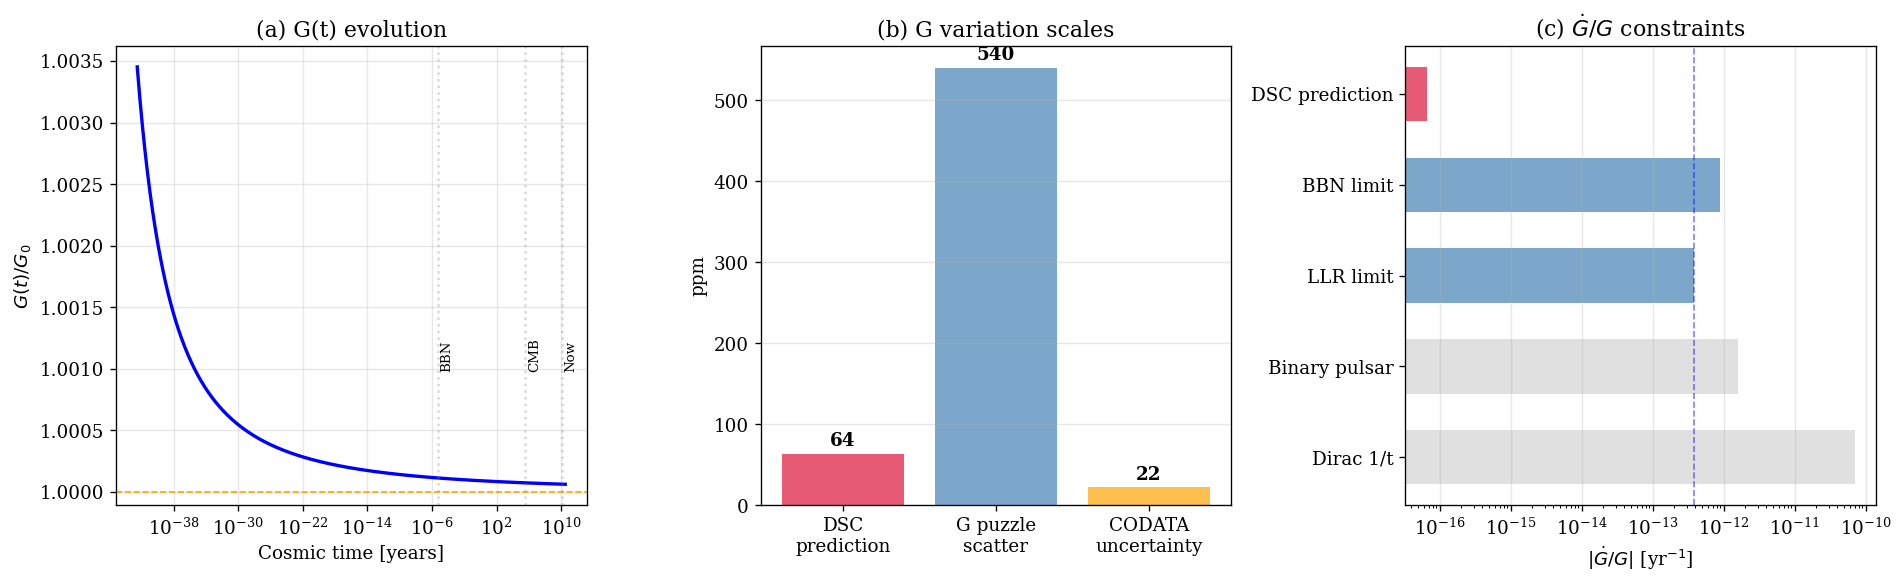

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) G(t) timeline
ax = axes[0]
t_arr = np.logspace(-35, 18, 500)
T_arr = t_arr / t_P
G_t = 1 + k_opt / np.log(np.maximum(T_arr, 10))**2
ax.semilogx(t_arr/3.156e7, G_t, 'b-', lw=2)
ax.axhline(1.0, color='orange', ls='--', lw=1)
for t_ep, lab in [(180/3.156e7,'BBN'), (1.2e13/3.156e7,'CMB'), (t_0/3.156e7,'Now')]:
    ax.axvline(t_ep, color='gray', ls=':', alpha=0.3)
    ax.text(t_ep*2, 1.001, lab, fontsize=8, rotation=90)
ax.set_xlabel('Cosmic time [years]')
ax.set_ylabel('$G(t)/G_0$')
ax.set_title('(a) G(t) evolution')
ax.grid(True, alpha=0.3)

# (b) Fluctuation comparison
ax = axes[1]
bars_data = {'DSC\nprediction': delta_G*1e6, 'G puzzle\nscatter': 540, 'CODATA\nuncertainty': 22}
ax.bar(bars_data.keys(), bars_data.values(), color=['crimson','steelblue','orange'], alpha=0.7)
ax.set_ylabel('ppm')
ax.set_title('(b) G variation scales')
for i, v in enumerate(bars_data.values()):
    ax.text(i, v+10, f'{v:.0f}', ha='center', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# (c) dG/dt/G constraints
ax = axes[2]
constr = {'Dirac 1/t': 7e-11, 'Binary pulsar': 1.6e-12,
          'LLR limit': 3.8e-13, 'BBN limit': 9e-13,
          'DSC prediction': dGdt_G}
cols = ['lightgray','lightgray','steelblue','steelblue','crimson']
ax.barh(list(constr.keys()), list(constr.values()), color=cols, alpha=0.7, height=0.6)
ax.set_xscale('log')
ax.set_xlabel(r'$|\dot{G}/G|$ [yr$^{-1}$]')
ax.set_title(r'(c) $\dot{G}/G$ constraints')
ax.axvline(3.8e-13, color='blue', ls='--', lw=1, alpha=0.5)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('fig3_G_constraints.png', dpi=150, bbox_inches='tight')
plt.show()